# Volatility Modeling

Volatility Clustering: สภาวะที่ "ถ้าวันนี้ตลาดผันผวนหนัก พรุ่งนี้ก็มีแนวโน้มจะผันผวนหนักต่อ" (Large changes tend to be followed by large changes).

1.1 ARCH (Autoregressive Conditional Heteroskedasticity)

พัฒนาโดย Robert Engle (1982) (ได้รับรางวัล Nobel จากงานนี้)Concept: ความแปรปรวน (Variance) ของวันนี้ ($\sigma_t^2$) ขึ้นอยู่กับ "Error" หรือผลตอบแทนที่ผิดปกติในอดีต ($\epsilon_{t-1}^2$)สมการ ARCH(q):$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i \epsilon_{t-i}^2$$ข้อจำกัด: เพื่อให้ model แม่นยำ อาจต้องใช้ค่า $q$ (Lag) เยอะมาก ซึ่งทำให้การคำนวณซับซ้อนและ parameters เยอะเกินไป

1.2 GARCH (Generalized ARCH)

พัฒนาต่อยอดโดย Tim Bollerslev (1986)Concept: แก้ปัญหาของ ARCH โดยบอกว่า ความแปรปรวนของวันนี้ ไม่ได้ขึ้นอยู่แค่ Error ในอดีต แต่ขึ้นอยู่กับ "ความแปรปรวนในอดีต" ($\sigma_{t-1}^2$) ด้วยสมการ GARCH(p, q): (ที่นิยมที่สุดคือ GARCH(1,1))

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

- (Omega): ค่าคงที่ (Weighted constant)$\alpha$ 
- (Alpha): ผลกระทบจากข่าวใหม่/Error ล่าสุด (Reaction to shock)$\beta$ 
- (Beta): ความทรงจำของความผันผวนเก่า (Persistence/Memory)

Key Insight: ค่า $\alpha + \beta$ ต้องน้อยกว่า 1 เสมอเพื่อให้ model เสถียร (Stationary) ยิ่งผลรวมเข้าใกล้ 1 แปลว่าความผันผวนจะคงอยู่นาน (Long memory process)

## Use Cases ที่น่าสนใจ

1. Risk Management (VaR): การคำนวณ Value at Risk แบบดั้งเดิมมักสมมติว่าความผันผวนคงที่ แต่ในวิกฤต ความผันผวนจะพุ่งสูง GARCH ช่วยให้เราปรับ VaR ได้แบบ Dynamic (ช่วงตลาดนิ่ง VaR ต่ำ ช่วงวิกฤต VaR สูงขึ้นทันที)

2. Option Pricing: Black-Scholes Model สมมติว่า Volatility คงที่ (Flat Vol) แต่ GARCH จะช่วยสร้าง Pricing Model ที่รองรับ "Volatility Smile" ได้ดีกว่า

3. Algorithmic Trading: ใช้ในการกำหนดขนาด Position (Position Sizing) ถ้า GARCH Forecast ว่าพรุ่งนี้ตลาดจะเหวี่ยงแรง ระบบจะลดขนาด Position ลงอัตโนมัติ

## Real World Strategy: "Volatility Targeting"

กลยุทธ์ที่ Hedge Funds นิยมใช้ โดยใช้ GARCH เป็นตัวขับเคลื่อน:

Strategy Concept:แทนที่จะถือหุ้น 100% ตลอดเวลา เราจะกำหนด Target Volatility (เช่น ยอมรับความผันผวนได้ 10% ต่อปี)Forecast: ใช้ GARCH(1,1) ทำนายความผันผวนของวันพรุ่งนี้ ($\hat{\sigma}_{t+1}$)Weighting: คำนวณน้ำหนักการลงทุน ($w_t$) ตามสูตร:

$$w_t = \frac{\text{Target Vol}}{\hat{\sigma}_{t+1}}$$

Action: 
 - ถ้า GARCH บอกว่าพรุ่งนี้ผันผวนต่ำ ($\hat{\sigma}$ ต่ำ) -> $w_t$ จะสูง (อาจใช้ Leverage ได้)
 - ถ้า GARCH บอกว่าพรุ่งนี้ผันผวนสูง ($\hat{\sigma}$ สูง) -> $w_t$ จะต่ำ (ลดพอร์ต ถือเงินสด)
 
ผลลัพธ์: ช่วยลด Drawdown ในช่วงตลาดขาลงรุนแรง (Market Crash) เพราะช่วงนั้น Volatility มักจะพุ่งสูงก่อนราคาจะลงหนักๆ

## Implementation

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

In [3]:
# 1. ดึงข้อมูล (ตัวอย่าง S&P 500)
data = yf.download('SPY', start='2020-01-01', end='2024-01-01',auto_adjust=False)
# คำนวณ Log Returns (คูณ 100 เพื่อให้ Scale เหมาะกับ Optimizer ของ GARCH)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [5]:
# 2. สร้างและ Train Model GARCH(1,1)
# vol='Garch': ระบุว่าเป็น GARCH
# p=1, q=1: ใช้ Lag 1 ทั้ง error และ variance
model = arch_model(returns, vol='Garch', p=1, q=1)
results = model.fit(disp='off') # disp='off' เพื่อไม่ให้ print log ระหว่าง train

In [6]:
# 3. ดูผลลัพธ์พารามิเตอร์
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1529.91
Distribution:                  Normal   AIC:                           3067.83
Method:            Maximum Likelihood   BIC:                           3087.48
                                        No. Observations:                 1005
Date:                Tue, Dec 30 2025   Df Residuals:                     1004
Time:                        12:55:15   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0845  3.047e-02      2.772  5.578e-03 [2.473e-0

In [7]:
# 4. การทำนายความผันผวน (Forecast)
# horizon=5: ทำนายล่วงหน้า 5 วัน
forecasts = results.forecast(horizon=5)

# ดึงค่า Variance ที่ทำนายได้ของวันล่าสุด
next_day_variance = forecasts.variance.iloc[-1]
next_day_volatility = np.sqrt(next_day_variance)

print("\n--- Forecast Results ---")
print(f"Predicted Volatility (Next 5 Days):\n{next_day_volatility}")


--- Forecast Results ---
Predicted Volatility (Next 5 Days):
h.1    0.708312
h.2    0.737780
h.3    0.765285
h.4    0.791055
h.5    0.815277
Name: 2023-12-29 00:00:00, dtype: float64


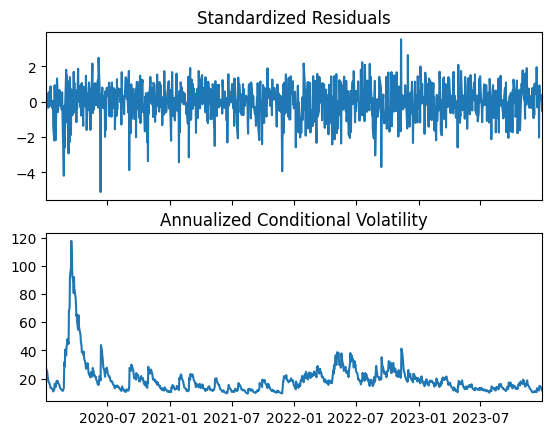

In [8]:
# 5. Plot Conditional Volatility ย้อนหลัง
fig = results.plot(annualize='D') # D for Daily
plt.show()

การอ่านค่า summary()
- ดูช่อง alpha[1]: ถ้าค่าสูง แปลว่าตลาดตอบสนองต่อข่าวใหม่รุนแรง (Jump ง่าย)

- ดูช่อง beta[1]: ถ้าค่าสูง (ใกล้ 1) แปลว่าเมื่อตลาดผันผวนแล้ว จะผันผวนไปอีกนาน (Memory ยาว)

# EGARCH (Exponential GARCH)
พัฒนาโดย Nelson (1991) เกิดมาเพื่อแก้ปัญหาที่ GARCH ทำไม่ได้ นั่นคือการแยกแยะระหว่าง "ข่าวร้าย" และ "ข่าวดี"

1. ปรากฏการณ์ "Leverage Effect" (หัวใจของเรื่องนี้)ก่อนดูสมการ ต้องเข้าใจพฤติกรรมตลาดจริงๆ ก่อน:

- GARCH (แบบเดิม): มองว่าถ้าตลาดขยับแรง 5% (ไม่ว่าจะ +5% หรือ -5%) ความผันผวนวันพรุ่งนี้จะเพิ่มขึ้น เท่ากัน (สมมาตร)

- ความจริง: ในตลาดหุ้น เวลามีข่าวร้าย (หุ้นตกหนัก) ความผันผวนมักจะระเบิดรุนแรงกว่าตอนมีข่าวดี (หุ้นขึ้นแรง) ปรากฏการณ์นี้เรียกว่า "Leverage Effect"

ทำไมถึงชื่อ Leverage Effect? 

ทฤษฎีบอกว่า เมื่อราคาหุ้นตก $\rightarrow$ มูลค่าบริษัทลดลง $\rightarrow$ อัตราส่วนหนี้สินต่อทุน (Debt-to-Equity) สูงขึ้น (บริษัทดูเสี่ยงขึ้น/Leverage สูงขึ้น) $\rightarrow$ หุ้นจึงมีความผันผวนสูงขึ้นในอนาคต

2. เจาะลึกสมการ EGARCH (The Math Logic)ความฉลาดของ Nelson คือการเปลี่ยนวิธีเขียนสมการใหม่ 2 จุดใหญ่ๆ:

จุดที่ 1: ใช้ Log Variance ($\ln \sigma_t^2$)ใน GARCH ธรรมดา เราต้องระวังมาก ห้ามให้ค่า $\omega, \alpha, \beta$ ติดลบ เพราะ Variance ($\sigma^2$) ติดลบไม่ได้แต่ใน EGARCH เรา Model ค่า Log ของมันแทน:$$\ln(\sigma_t^2) = ...$$

- ข้อดี: ค่าทางขวาของสมการจะเป็นลบก็ได้ ไม่เป็นไร เพราะเมื่อเราแปลงกลับเป็น Variance (ใช้ $e^{\ln...}$) ค่าจะเป็นบวกเสมอ ทำให้การหา Parameter ยืดหยุ่นกว่ามาก

จุดที่ 2: เทอมที่จับความไม่สมมาตร (Asymmetry Term)สมการของ EGARCH(1,1) หน้าตาประมาณนี้ (แบบย่อ):

$$\ln(\sigma_t^2) = \omega + \beta \ln(\sigma_{t-1}^2) + \underbrace{\alpha \left( \left| \frac{\epsilon_{t-1}}{\sigma_{t-1}} \right| - E[...] \right)}_{\text{ขนาด (Magnitude)}} + \underbrace{\gamma \frac{\epsilon_{t-1}}{\sigma_{t-1}}}_{\text{ทิศทาง (Sign)}}$$

สังเกต 2 เทอมหลัง:

1. Term $\alpha$ (Magnitude): ดูแค่ "ขนาด" ของการเปลี่ยนแปลง (ใส่ Absolute $|...|$) เหมือน GARCH ปกติ คือถ้าเหวี่ยงแรง Vol ก็เพิ่ม
    
2. Term $\gamma$ (Gamma - The Sign Effect): จุดเด่นสำคัญ มันไม่มี Absolute ครอบ แปลว่ามันสนใจเครื่องหมาย บวก/ลบ

- ถ้า $\epsilon_{t-1}$ เป็น บวก (ข่าวดี) $\rightarrow$ เทอมนี้จะบวกเพิ่มเข้าไป
- ถ้า $\epsilon_{t-1}$ เป็น ลบ (ข่าวร้าย) $\rightarrow$ เทอมนี้จะกลายเป็นลบ

3. การอ่านค่า $\gamma$ (Gamma)

เมื่อรัน Model EGARCH เสร็จ สิ่งที่ต้องดูเป็นอันดับแรกคือค่าสัมประสิทธิ์ $\gamma$ (Gamma) :

- ถ้า $\gamma < 0$ (ติดลบ): "เจอข่าวร้าย ตลาดจะผันผวนหนักกว่าข่าวดี"
    - นี่คือสิ่งที่เจอในตลาดหุ้นเกือบ 100%  (Negative Asymmetry)
    - อธิบาย: เมื่อเกิด Shock ที่เป็นลบ (หุ้นตก) ค่าลบของ Shock จะไปคูณกับ $\gamma$ ที่เป็นลบ ผลลัพธ์กลายเป็น บวก (ลบ x ลบ = บวก) ส่งผลให้ $\ln(\sigma^2)$ ดีดตัวสูงขึ้นอย่างมาก
    
- ถ้า $\gamma > 0$ (เป็นบวก): "เจอข่าวดี ตลาดจะผันผวนหนักกว่าข่าวร้าย" (มักไม่ค่อยเจอในหุ้น แต่อาจเจอในสินค้าโภคภัณฑ์บางตัว)
- ถ้า $\gamma = 0$: EGARCH จะกลายร่างกลับเป็น GARCH ธรรมดา (Symmetric)

4. เปรียบเทียบกราฟ News Impact Curve
เพื่อให้เห็นภาพชัดที่สุด นัก Quant จะพล็อตกราฟที่เรียกว่า News Impact Curve:

- แกน X: ข่าว (Shock) ล่าสุด (บวก/ลบ)

- แกน Y: ความผันผวนที่ทำนายได้ของวันพรุ่งนี้

1. GARCH: กราฟเป็นรูปตัว U สมมาตร (ซ้ายขวาเท่ากันเป๊ะ)

2. EGARCH: กราฟเป็นรูป "เครื่องหมายถูก" (Check mark) หรือตัว U เบี้ยวๆ

        - ฝั่งซ้าย (ข่าวร้าย) กราฟจะชันสูงปรี๊ด (Vol พุ่ง)

        - ฝั่งขวา (ข่าวดี) กราฟจะลาดขึ้นนิดเดียว หรือบางทีลาดลงด้วยซ้ำ (ตลาดสงบเมื่อหุ้นขึ้น)

## Implementation

In [1]:
from arch import arch_model
import yfinance as yf
import numpy as np

In [2]:
# 1. Prepare Data (เหมือนเดิม)
data = yf.download('SPY', start='2020-01-01', end='2024-01-01',auto_adjust=False)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [3]:
# 2. Train EGARCH Model
# vol='EGarch': ระบุว่าเป็น Exponential GARCH
# p=1, q=1: Lag parameters
model = arch_model(returns, vol='EGarch', p=1, q=1)
results = model.fit(disp='off')

In [4]:
# 3. ดูผลลัพธ์
print(results.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -1534.88
Distribution:                  Normal   AIC:                           3077.76
Method:            Maximum Likelihood   BIC:                           3097.41
                                        No. Observations:                 1005
Date:                Tue, Dec 30 2025   Df Residuals:                     1004
Time:                        16:19:07   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0803  2.956e-02      2.717  6.580e-03 [2.239e-0

สิ่งที่ต้องสังเกตใน results.summary(): มองหาบรรทัดที่เขียนว่า gamma[1] (บางที Library อาจใช้ชื่ออื่นแต่จะสื่อถึง Asymmetry parameter)

ถ้าค่า t-statistic ของ Gamma สูงๆ (เช่น > 2 หรือ < -2) และ P>|t| ต่ำกว่า 0.05

แปลว่า "ตลาดนี้มี Leverage Effect จริง อย่างมีนัยสำคัญ" การใช้ EGARCH จึงถูกต้องและแม่นยำกว่า GARCH ธรรมดา

# บทสรุปเชิงกลยุทธ์
ถ้ากำลังจะทำ Bot Trade หรือ Risk Model:

Crypto: บางเหรียญอาจจะไม่มี Leverage Effect ชัดเจนเท่าหุ้น (เพราะขึ้นแรงคนก็ FOMO แห่ซื้อจนผันผวนหนักเหมือนกัน) -> ต้องลอง Test ดูค่า Gamma ก่อน

Stocks/Indices: ควรใช้ EGARCH เป็น Default แทน GARCH ธรรมดา เพราะธรรมชาติของตลาดหุ้นคือ "ขึ้นบันได (ค่อยๆ ขึ้น) แต่ลงลิฟต์ (ลงแรง)"

VaR (Risk Management): การใช้ EGARCH จะช่วยป้องกันการประเมินความเสี่ยงต่ำเกินไป (Underestimate Risk) ในช่วงตลาดขาลง

# Backtest GARCH VS EGARCH

Backtest
เปรียบเทียบ 3 กลยุทธ์:

1. Buy & Hold (Benchmark): ถือ SPY (S&P 500) ยาวๆ รับแรงกระแทกเต็มๆ

2. GARCH(1,1) Volatility Targeting: ปรับพอร์ตโดยใช้ GARCH ธรรมดา

3. EGARCH(1,1) Volatility Targeting: ปรับพอร์ตโดยใช้ EGARCH (พระเอกของเรา)

สมมติฐาน: EGARCH ควรจะจับสัญญาณ "Panic" ได้ไวกว่า และสั่งลดพอร์ต (หนีตาย) ได้เร็วกว่า GARCH ธรรมดา ทำให้ขาดทุนน้อยกว่า (Drawdown ต่ำกว่า)

## Implementation
Rolling Forecast (ทำนายวันต่อวัน) เพื่อจำลองสถานการณ์จริงที่ไม่รู้อนาคต

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt
import warnings

In [6]:
warnings.filterwarnings("ignore")

In [7]:
# ---------------------------------------------------------
# 1. Prepare Data
# ---------------------------------------------------------
# ใช้ข้อมูลย้อนหลังยาวหน่อยเพื่อให้ Model เรียนรู้ Pattern
symbol = 'SPY'
data = yf.download(symbol, start='2015-01-01', end='2021-01-01', auto_adjust=False)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [8]:
# แบ่งช่วงเวลา: Test ตั้งแต่ปี 2020 (ช่วงโควิด)
test_start_date = '2020-01-01'
test_data = returns[test_start_date:]
train_data_len = len(returns) - len(test_data)

print(f"Total Days to Backtest: {len(test_data)} days")
print("Starting simulation... (This might take a minute)")

Total Days to Backtest: 253 days
Starting simulation... (This might take a minute)


In [9]:
# ---------------------------------------------------------
# 2. Rolling Forecast Loop
# ---------------------------------------------------------
# เก็บผลลัพธ์ความผันผวน

garch_vol = []
egarch_vol = []

# Loop เทรดจริงทีละวัน
for i in range(len(test_data)):
    # ข้อมูลที่เรารู้ ณ วันนั้น (ตั้งแต่ต้น จนถึงเมื่อวาน)
    current_returns = returns[:train_data_len + i]
    
    # A. Train GARCH (Standard)
    # disp='off' เพื่อไม่ให้ print log
    model_garch = arch_model(current_returns, vol='Garch', p=1, q=1)
    res_garch = model_garch.fit(disp='off')
    # Forecast วันถัดไป (horizon=1)
    forecast_garch = res_garch.forecast(horizon=1).variance.iloc[-1, 0]
    garch_vol.append(np.sqrt(forecast_garch))
    
    # B. Train EGARCH (Asymmetric)
    model_egarch = arch_model(current_returns, vol='EGarch', p=1, q=1)
    res_egarch = model_egarch.fit(disp='off')
    forecast_egarch = res_egarch.forecast(horizon=1).variance.iloc[-1, 0]
    egarch_vol.append(np.sqrt(forecast_egarch))

In [10]:
# แปลงเป็น Series เพื่อให้ง่ายต่อการคำนวณ
vol_df = pd.DataFrame({
    'GARCH_Vol': garch_vol, 
    'EGARCH_Vol': egarch_vol
}, index=test_data.index)

In [11]:
# ---------------------------------------------------------
# 3. Strategy Logic: Volatility Targeting
# ---------------------------------------------------------
target_vol = 1.0  # เป้าหมายความผันผวนต่อวัน (ประมาณ 16% ต่อปี)

# สูตร: Weight = Target / Forecast
# ถ้า Forecast สูง -> Weight น้อย (ถือเงินสดเยอะ)
# Clip ไว้ไม่ให้เกิน 1.5 (Leverage ได้นิดหน่อย)
strategy_df = pd.DataFrame(index=test_data.index)
strategy_df['Return_BuyHold'] = test_data / 100 # แปลงกลับจาก % เป็นทศนิยม

# คำนวณ Weight
strategy_df['Weight_GARCH'] = (target_vol / vol_df['GARCH_Vol']).clip(upper=1.5)
strategy_df['Weight_EGARCH'] = (target_vol / vol_df['EGARCH_Vol']).clip(upper=1.5)

# คำนวณกำไรพอร์ต (Weight * Return หุ้น)
# shift(1) เพราะเราตัดสินใจ Weight จากข้อมูลเมื่อวาน มาใช้เทรดวันนี้
strategy_df['Return_GARCH'] = strategy_df['Weight_GARCH'].shift(1) * strategy_df['Return_BuyHold']
strategy_df['Return_EGARCH'] = strategy_df['Weight_EGARCH'].shift(1) * strategy_df['Return_BuyHold']

# Wealth Curve (เงินต้น 100)
strategy_df['Wealth_BuyHold'] = 100 * (1 + strategy_df['Return_BuyHold']).cumprod()
strategy_df['Wealth_GARCH'] = 100 * (1 + strategy_df['Return_GARCH'].fillna(0)).cumprod()
strategy_df['Wealth_EGARCH'] = 100 * (1 + strategy_df['Return_EGARCH'].fillna(0)).cumprod()

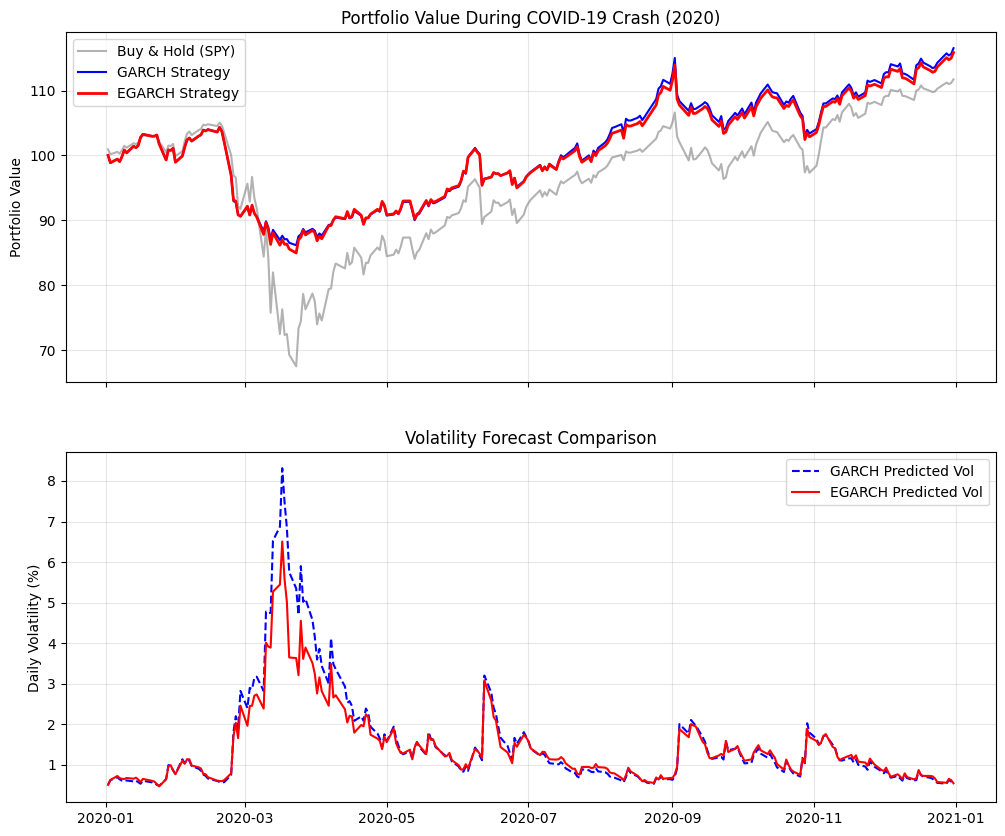

Max Drawdown (Buy & Hold): -35.75%
Max Drawdown (GARCH): -17.44%
Max Drawdown (EGARCH): -18.57%


In [12]:
# ---------------------------------------------------------
# 4. Plot Results
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Graph 1: Wealth Curve
ax1.plot(strategy_df['Wealth_BuyHold'], label='Buy & Hold (SPY)', color='gray', alpha=0.6)
ax1.plot(strategy_df['Wealth_GARCH'], label='GARCH Strategy', color='blue')
ax1.plot(strategy_df['Wealth_EGARCH'], label='EGARCH Strategy', color='red', linewidth=2)
ax1.set_title('Portfolio Value During COVID-19 Crash (2020)')
ax1.set_ylabel('Portfolio Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Predicted Volatility
ax2.plot(vol_df['GARCH_Vol'], label='GARCH Predicted Vol', color='blue', linestyle='--')
ax2.plot(vol_df['EGARCH_Vol'], label='EGARCH Predicted Vol', color='red')
ax2.set_title('Volatility Forecast Comparison')
ax2.set_ylabel('Daily Volatility (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

# คำนวณ Max Drawdown คร่าวๆ
def get_max_drawdown(wealth_series):
    peak = wealth_series.cummax()
    drawdown = (wealth_series - peak) / peak
    return drawdown.min() * 100

print(f"Max Drawdown (Buy & Hold): {get_max_drawdown(strategy_df['Wealth_BuyHold']):.2f}%")
print(f"Max Drawdown (GARCH): {get_max_drawdown(strategy_df['Wealth_GARCH']):.2f}%")
print(f"Max Drawdown (EGARCH): {get_max_drawdown(strategy_df['Wealth_EGARCH']):.2f}%")

# Fat Tail Distribution

ถ้าสมมติว่าผลตอบแทนตลาดหุ้นมีการแจกแจงแบบ Normal (ระฆังคว่ำปกติ):

- เหตุการณ์ที่ตลาดจะลบหนักๆ (เช่น -5% หรือ -10% ในวันเดียว) ทางสถิติบอกว่า "แทบเป็นไปไม่ได้" (อาจจะเกิด 1 ครั้งในรอบล้านปี)

- ความเป็นจริง: เราเห็นตลาดพัง (Crash) แทบทุก 10 ปี (Tom Yum Kung, Subprime, Covid)

Fat Tail (หางอ้วน) คือกราฟระฆังคว่ำที่ "ปลายหางยกสูงกว่าปกติ" แปลว่า: โอกาสเกิดเหตุการณ์สุดโต่ง (Extreme Events) มีมากกว่าที่โมเดลปกติคาดการณ์ไว้

ถ้าเกิดเหตุการณ์สุดโต่ง (Extreme Event) จะเกิดอะไรขึ้น?
- Model ปกติ (Normal): จะมองว่าเหตุการณ์นี้คือ Outlier ที่ผิดปกติมากๆ (Shock) อาจทำให้ค่าความผันผวนดีดตัวผิดเพี้ยน หรือประเมินความเสี่ยงต่ำเกินไป (Underestimate Risk)

- Model หางอ้วน (Student's t): จะมองว่า "อ๋อ... เหตุการณ์ลบหนักๆ แบบนี้มันเกิดขึ้นได้นะ" โมเดลจะเตรียมเผื่อใจไว้แล้ว ทำให้การคำนวณความเสี่ยง (Risk Metric) แม่นยำและสมจริงกว่า

## Student's t-distribution

วงการ Quant เรามักจะเปลี่ยนจาก Normal Distribution มาใช้ Student's t-distribution แทน เพราะมันมี Parameter ตัวนึงที่ชื่อว่า "Degrees of Freedom" ($\nu$ - นู)
- ค่า $\nu$ นี้จะคอยคุมความอ้วนของหาง
- ยิ่ง $\nu$ ต่ำ $\rightarrow$ หางยิ่งอ้วน (รับรองวิกฤตได้ดี)
- ยิ่ง $\nu$ สูง (เข้าใกล้ Infinity) $\rightarrow$ หางจะแฟบลงจนกลายเป็น Normal Distribution ปกติ

## Implementation

ใน function arch_model แค่ปรับ parameter dist='t' เข้าไป

In [13]:
from arch import arch_model
import yfinance as yf
import numpy as np

In [14]:
# 1. ข้อมูล (SPY เหมือนเดิม)
data = yf.download('SPY', start='2020-01-01', end='2024-01-01',auto_adjust=False)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [15]:
# 2. สร้าง Model: EGARCH + Student's t-distribution
# dist='t' : บอกให้ใช้ t-distribution (Fat Tail)
# vol='EGarch' : ยังคงใช้ EGARCH เพื่อจับข่าวร้าย
model_fat_tail = arch_model(returns, vol='EGarch', p=1, q=1, dist='t')

In [16]:
# 3. Fit Model
res_fat_tail = model_fat_tail.fit(disp='off')

print(res_fat_tail.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1517.26
Distribution:      Standardized Student's t   AIC:                           3044.51
Method:                  Maximum Likelihood   BIC:                           3069.07
                                              No. Observations:                 1005
Date:                      Tue, Dec 30 2025   Df Residuals:                     1004
Time:                              17:14:48   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

Summary: ให้ดูบรรทัดล่างสุดในตาราง parameter จะมีตัวแปรชื่อ nu (Degrees of Freedom)

- ถ้าค่า nu อยู่แถวๆ 4 ถึง 8 แปลว่าข้อมูลนี้มี Fat Tail ชัดเจนมาก (ตลาดหุ้นส่วนใหญ่จะอยู่ประมาณ 6-7)

- ค่า nu นี้แหละ คือตัวบอกว่าตลาดนี้ "บ้าคลั่ง" (เกิด Extreme event) บ่อยแค่ไหน

## Use Case จริง: การคำนวณ Value at Risk (VaR)

สมมติถ้าอยากรู้ว่า "พรุ่งนี้มีโอกาส 1% ที่เราจะขาดทุนสูงสุดเท่าไหร่?" (VaR 99%)

ถ้าใช้ Model ปกติ vs Model Fat Tail ผลลัพธ์จะต่างกันมหาศาล:

``` 
    # สมมติ Model ทำนายว่า Volatility พรุ่งนี้ = 1.0%

    # A. แบบ Normal Distribution (Z-score 99% = 2.33)
    # VaR = Volatility * 2.33
    var_normal = 1.0 * 2.33 
    # ผลลัพธ์: บอกว่าเสี่ยงสุดๆ แค่ -2.33%

    # B. แบบ Fat Tail (t-distribution, สมมติ nu=6)
    # t-statistic ที่ 99% ของ nu=6 คือประมาณ 3.14 (สูงกว่าปกติเยอะ)
    # VaR = Volatility * 3.14
    var_t = 1.0 * 3.14
    # ผลลัพธ์: บอกว่าเสี่ยงถึง -3.14%
```

## สรุปความสำคัญ
การใช้ Fat Tail (dist='t') คู่กับ EGARCH คือ Combo มาตรฐานของสาย Quant :

1. EGARCH: จับพฤติกรรม "ตกใจข่าวร้าย" (Asymmetry)

2. Student's t: จับพฤติกรรม "เกิดเรื่องไม่คาดฝันบ่อย" (Extreme Events)

เมื่อรวมกัน โมเดลเราจะ "กลัว" และ "ระมัดระวังตัว" มากขึ้น ซึ่งเป็นคุณสมบัติที่ดีที่สุดของระบบบริหารความเสี่ยง

# VaR (Value at Risk) Simulation

VaR คือตัวเลขที่บอกว่า: "ด้วยความมั่นใจ X% พรุ่งนี้เราจะไม่ขาดทุนเกิน ... บาท"
- ตัวอย่าง: "VaR 99% = 10,000 บาท"
- แปลว่า: มีโอกาส 99% ที่พรุ่งนี้เราจะขาดทุนไม่เกิน 1 หมื่น (หรือมีโอกาสแค่ 1% เท่านั้นที่จะซวยหนักกว่า 1 หมื่น)

สูตรคำนวณ VaR (แบบ Parametric)

$$VaR = \text{เงินต้น} \times \sigma_{forecast} \times \text{Factor ความมั่นใจ}$$

จุดตายอยู่ที่ "Factor ความมั่นใจ"
- ถ้าเชื่อ Normal Dist: ใช้ค่า Z-score (เช่น 95% = 1.65, 99% = 2.33)
- ถ้าเชื่อ Student's t (Fat Tail): ต้องเปิดตาราง t-stat ตามค่า nu ที่ model บอก (ค่าจะสูงกว่า Z-score เสมอ)

## Implementation: คำนวณ VaR รายวัน

จำลองว่าถ้าเรามีเงิน 1 ล้านบาท และใช้ Model EGARCH + Fat Tail คำนวณความเสี่ยงทุกวัน ผลจะเป็นยังไง

In [17]:
from arch import arch_model
from scipy.stats import t, norm
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [18]:
# 1. เตรียมข้อมูล
data = yf.download('SPY', start='2018-01-01', end='2021-01-01',auto_adjust=False)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()
portfolio_value = 1_000_000  # เงินต้น 1 ล้านบาท
confidence_level = 0.99      # ความมั่นใจ 99% (ยอมเสี่ยง 1%)

[*********************100%***********************]  1 of 1 completed


In [19]:
# 2. Train Model (EGARCH + Student's t)
# ใช้ข้อมูลทั้งหมดเพื่อให้ง่ายต่อการสาธิต (ในความจริงต้องทำ Rolling Forecast)
model = arch_model(returns, vol='EGarch', p=1, q=1, dist='t')
res = model.fit(disp='off')

In [22]:
print(res.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1030.24
Distribution:      Standardized Student's t   AIC:                           2070.48
Method:                  Maximum Likelihood   BIC:                           2093.61
                                              No. Observations:                  755
Date:                      Tue, Dec 30 2025   Df Residuals:                      754
Time:                              17:34:22   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [20]:
# 3. ดึงค่าพารามิเตอร์สำคัญ
forecasts = res.conditional_volatility # ค่าความผันผวนรายวัน (Sigma)
nu = res.params['nu']                  # ค่า Degrees of Freedom (ความอ้วนของหาง)

In [23]:
print(f"Degrees of Freedom (nu): {nu:.2f}")

Degrees of Freedom (nu): 5.10


In [24]:
# 4. คำนวณ VaR Factor (ตัวคูณความเข้มงวด)
# แบบ Normal (Z-score)
z_score = norm.ppf(confidence_level)

# แบบ Fat Tail (t-statistic)
t_stat = t.ppf(confidence_level, df=nu)

print(f"Normal Factor (Z): {z_score:.2f}")
print(f"Fat Tail Factor (t): {t_stat:.2f}")
print(f"-> โมเดล Fat Tail เผื่อความเสี่ยงมากกว่า Normal: {((t_stat/z_score)-1)*100:.1f}%")

Normal Factor (Z): 2.33
Fat Tail Factor (t): 3.34
-> โมเดล Fat Tail เผื่อความเสี่ยงมากกว่า Normal: 43.4%


In [25]:
# 5. คำนวณ VaR เป็นตัวเงิน
# สูตร: เงินต้น * (Volatility/100) * Factor
# หาร 100 เพราะ Volatility เป็นหน่วย %
var_normal_series = portfolio_value * (forecasts / 100) * z_score
var_fat_tail_series = portfolio_value * (forecasts / 100) * t_stat

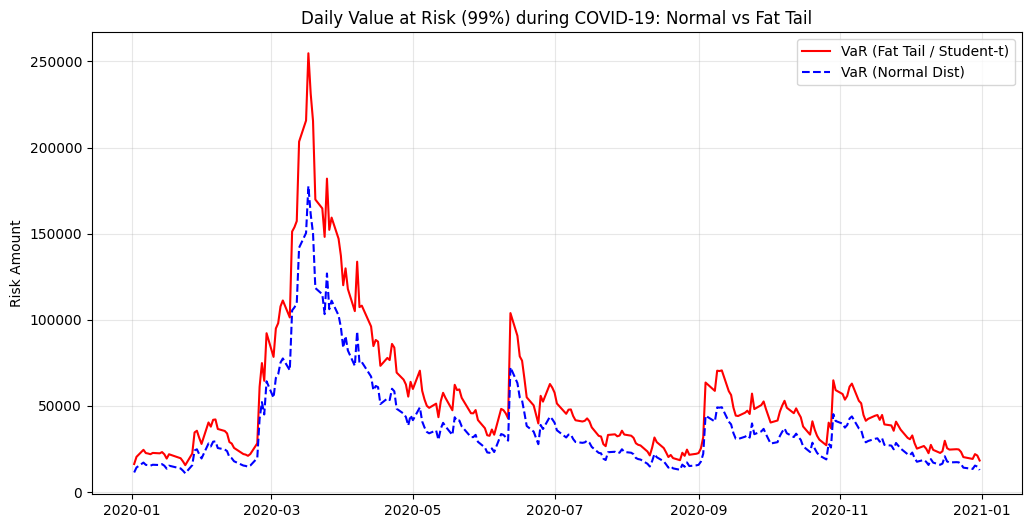

In [27]:
# 6. Plot กราฟเปรียบเทียบ
plt.figure(figsize=(12, 6))
plt.plot(var_fat_tail_series['2020-01-01':], label='VaR (Fat Tail / Student-t)', color='red')
plt.plot(var_normal_series['2020-01-01':], label='VaR (Normal Dist)', color='blue', linestyle='--')
plt.title('Daily Value at Risk (99%) during COVID-19: Normal vs Fat Tail')
plt.ylabel('Risk Amount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

กราฟและผลลัพธ์
1. ค่า Factor (t vs Z):

    - z_score (Normal) จะอยู่ที่ประมาณ 2.33

    - t_stat (Fat Tail) ถ้า nu ประมาณ 6-7 ค่าจะกระโดดไปแถวๆ 2.8 - 3.0

    - ความหมาย: Model แบบ Fat Tail จะบอกว่า "เผื่อความเสี่ยงไว้อีกหน่อย" (Buffer สูงกว่าประมาณ 20-30%)

2. ช่วงวิกฤต (Covid-19):

    - เส้นสีแดง (Fat Tail VaR) จะพุ่งสูงมาก (อาจแตะหลักแสนต่อวัน)

    - ถ้าเราเป็น Risk Manager แล้วใช้เส้นสีฟ้า (Normal) เราอาจจะกันเงินสำรองไว้ไม่พอสำหรับความผันผวนระดับนั้น

## การนำไปใช้กับ Bot Trade (Real World)

```
# Logic ตัวอย่าง
daily_risk_limit = 50000  # ยอมรับการขาดทุนได้สูงสุดวันละ 50,000 บาท

current_var = var_fat_tail_series.iloc[-1] # VaR ของวันนี้

if current_var > daily_risk_limit:
    # Action: ลดขนาดพอร์ตทันที
    reduce_ratio = daily_risk_limit / current_var
    print(f"ความเสี่ยงเกินลิมิต! ลดพอร์ตลงเหลือ {reduce_ratio*100:.1f}%")
    # Bot.sell(position * (1-reduce_ratio))
else:
    print("ความเสี่ยงปกติ เทรดต่อได้")
```

# Model Selection & Optimization

"ถ้าโมเดล 2 ตัวให้ผลลัพธ์ใกล้เคียงกัน ให้เลือกตัวที่ ง่าย ที่สุดเสมอ"

ถ้าเราใช้ GARCH(5,5) มันอาจจะ Fit เส้นกราฟในอดีตได้เป๊ะมาก (Overfitting) แต่พอเอาไปใช้จริงอาจจะเจ๊ง เพราะมันจำ "Noise" ในอดีตมาด้วย เราจึงต้องมีตัวชี้วัดมาคัดเลือกและเอาโมเดลที่ซับซ้อนเกินความจำเป็นออกไป


AIC และ BIC
เราใช้ค่า Score สองตัวนี้ในการตัดสิน:

- AIC (Akaike Information Criterion)

- BIC (Bayesian Information Criterion)

กฎเหล็ก: ยิ่งค่า ต่ำ (Lower) = ยิ่ง ดี

- ทั้งสองค่านี้คำนวณจาก: (ความแม่นยำ) - (บทลงโทษความซับซ้อน)

- ยิ่งใส่ p, q เยอะๆ บทลงโทษจะยิ่งสูง ทำให้ค่า AIC/BIC สูงขึ้น (แย่ลง) เว้นแต่ว่าความซับซ้อนนั้นจะช่วยให้แม่นยำขึ้นจริงๆ

## Code Implementation: Grid Search หาค่า p, q ที่ดีที่สุด

เขียน Loop ง่ายๆ เพื่อทดลองจับคู่ p และ q หลายๆ แบบ แล้วดูว่าคู่ไหนให้ AIC ต่ำที่สุด

In [28]:
from arch import arch_model
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [29]:
# 1. ข้อมูล
data = yf.download('SPY', start='2020-01-01', end='2024-01-01',auto_adjust=False)
returns = 100 * np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [30]:
# 2. กำหนดช่วงที่จะค้นหา (เช่น ลอง p=1-3, q=1-3)
p_range = range(1, 4)
q_range = range(1, 4)

best_aic = float('inf') # ตั้งค่าเริ่มต้นให้สูงๆ ไว้ก่อน
best_param = None
results_list = []

print("Starting Grid Search...")

Starting Grid Search...


In [31]:
# 3. Loop Grid Search
for p in p_range:
    for q in q_range:
        try:
            # สร้างและเทรนโมเดล (ใช้ EGARCH + t-dist ที่เราเรียนมา)
            model = arch_model(returns, vol='EGarch', p=p, q=q, dist='t')
            res = model.fit(disp='off')
            
            # เก็บค่า AIC
            current_aic = res.aic
            results_list.append({'p': p, 'q': q, 'AIC': current_aic, 'BIC': res.bic})
            
            print(f"Tested EGARCH({p},{q}) -> AIC: {current_aic:.2f}")
            
            # เช็คว่าเป็นตัวที่ดีที่สุดหรือยัง
            if current_aic < best_aic:
                best_aic = current_aic
                best_param = (p, q)
                
        except:
            continue # ถ้าโมเดล Error ให้ข้ามไป

Tested EGARCH(1,1) -> AIC: 3044.51
Tested EGARCH(1,2) -> AIC: 3046.51
Tested EGARCH(1,3) -> AIC: 3048.51
Tested EGARCH(2,1) -> AIC: 3045.66
Tested EGARCH(2,2) -> AIC: 3047.34
Tested EGARCH(2,3) -> AIC: 3048.64
Tested EGARCH(3,1) -> AIC: 3046.62
Tested EGARCH(3,2) -> AIC: 3048.62
Tested EGARCH(3,3) -> AIC: 3050.24


In [32]:
# 4. สรุปผล
print("\n" + "="*30)
print(f"WINNER: EGARCH{best_param} with AIC: {best_aic:.2f}")
print("="*30)

# แสดงตารางเทียบ
df_results = pd.DataFrame(results_list).sort_values('AIC')
print(df_results)


WINNER: EGARCH(1, 1) with AIC: 3044.51
   p  q          AIC          BIC
0  1  1  3044.510562  3069.074276
3  2  1  3045.659531  3075.135988
1  1  2  3046.510266  3075.986722
6  3  1  3046.623104  3081.012304
4  2  2  3047.344304  3081.733504
2  1  3  3048.510266  3082.899465
7  3  2  3048.623105  3087.925047
5  2  3  3048.638924  3087.940866
8  3  3  3050.241002  3094.455687


จะเห็นว่า EGARCH(1,1) หรือ EGARCH(1,2) ชนะเลิศ

เป็นเหตุผลว่าทำไมใน paper วิชาการหรือในงาน Quant ส่วนใหญ่ ถึงใช้แค่ (1,1) เป็นค่า Default เพราะเพิ่ม (2,2) ไปก็ไม่ค่อยคุ้มค่าเหนื่อย (AIC ไม่ลดลงอย่างมีนัยสำคัญ)

## การตรวจสุขภาพโมเดล (Residual Diagnostics)

เลือกโมเดลที่ AIC ต่ำสุดแล้ว จบเลยไหม? ยังครับ! ต้องเช็คว่า "ขยะ" (Residuals) ที่โมเดลทิ้งไว้ มันสะอาดจริงไหม?

ถ้าโมเดลเราดีจริง ค่า Error (Standardized Residuals) ที่เหลืออยู่ควรจะเป็น White Noise:

1. ไม่มี Pattern หลงเหลือ: ไม่ใช่ว่าช่วงแรก Error เป็นบวกยาวๆ ช่วงหลัง Error เป็นลบยาวๆ

2. ไม่มี Autocorrelation: Error ของวันนี้ ไม่ควรสัมพันธ์กับ Error เมื่อวาน

วิธีเช็คด้วยกราฟ (ACF Plot):

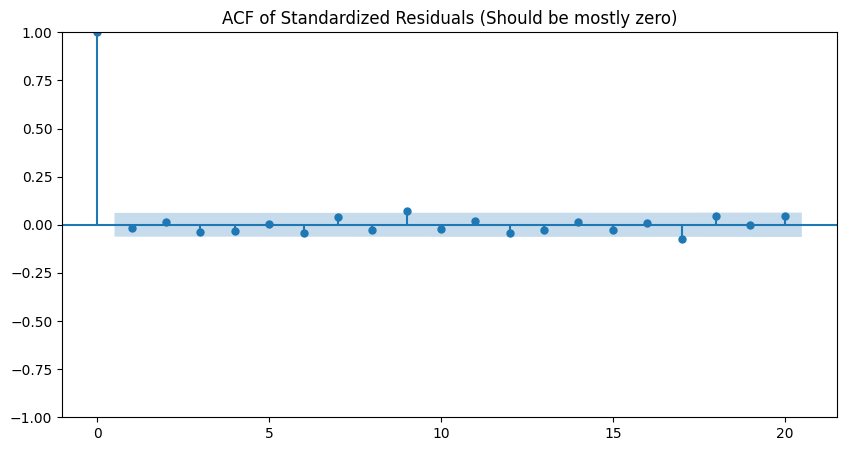

In [33]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# สร้างโมเดลผู้ชนะ (สมมติว่าเป็น 1,1)
best_model = arch_model(returns, vol='EGarch', p=1, q=1, dist='t')
best_res = best_model.fit(disp='off')

# ดึงค่า Standardized Residuals
std_resid = best_res.std_resid

# Plot ACF (AutoCorrelation Function)
# ถ้าแท่งกราฟส่วนใหญ่อยู่ในกรอบสีฟ้า = ผ่าน (เป็น White Noise)
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(std_resid, ax=ax, lags=20)
plt.title('ACF of Standardized Residuals (Should be mostly zero)')
plt.show()

ถ้ากราฟแท่งส่วนใหญ่อยู่ใน "แถบสีฟ้า" (Confidence Interval) แปลว่าโมเดล ผ่านการตรวจสอบ (Valid) พร้อมนำไปใช้งานจริง (Production)